# Projekt 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych

**Autorzy**: Kalina Rączka, Emilia Sarna

**Data**: 28.05.2026

### Charakterystyka wybranego środowiska

LunarLanderContinuous-v3 to środowisko z przestrzenią stanów ciągłych (8 cech: położenie landera, prędkości, kąt, prędkość kątowa oraz kontakty nóżek z podłożem) i akcjami ciągłymi (2 silniki w zakresie [-1, 1]).

Nagroda ma charakter pomocniczy i etapowy (reward shaping) i zależy m.in. od stabilności lotu, bliskości platformy oraz bezpiecznego lądowania. Epizod kończy się po wylądowaniu, rozbiciu lub opuszczeniu obszaru.

### Charakterystyka algortymu

Zostały zastosowane trzy algorytmy z biblioteki stable-baselines3 przystosowane do sterowania w przestrzeniach ciągłych: 
- PPO (on-policy) - PPO uczy się wyłącznie na danych, które sam przed chwilą zebrał, używając swojej najnowszej strategii (polityki). Gdy zaktualizuje wagę sieci neuronowej, stare dane zostają odrzucane, a agent musi zebrać nowe doświadczenia. Posiada specjalną funkcję celu, która ogranicza krok nauki. Dzięki temu nowa strategia nie różni się drastycznie od starej, co zapobiega nagłemu "rozsypaniu się" modelu podczas treningu.
- SAC (entropy + off-policy) - Jako algorytm off-policy, SAC zapisuje wszystkie swoje historyczne próby (udane i nieudane) do tzw. Replay Buffer (pamięci powtórek) i losuje z niej próbki do nauki. Dodatkowo, SAC jest nagradzany za bycie losowym (wysoka entropia). Agent stara się wykonać zadanie, ale w taki sposób, by zachować jak najwięcej alternatywnych ścieżek ruchu.

### Wybrane hiperparametry

Dla każdego algorytmu przygotowano trzy zestawy hiperparametrów. Każdy zestaw uruchamiany jest 10 razy po 50 000 krokow czasowych.

Poniżej przedstawiono zestawy hiperparametrów dla poszczególnych procesów uczenia oraz czas potrzebny na naukowę jednego kroku czasowego oraz epizodu.

In [7]:
from pathlib import Path
import json

RESULTS_DIR = Path("results")

def _fmt(value, ndigits=3):
    if value is None:
        return "n/a"
    return f"{value:.{ndigits}f}"

def load_config_rows():
    rows = []
    for summary_path in RESULTS_DIR.rglob("summary.json"):
        algo = summary_path.parent.parent.name
        if algo == "TD3":
            continue
        config = summary_path.parent.name
        with open(summary_path, "r", encoding="utf-8") as file:
            summary = json.load(file)
        params_path = summary_path.parent / "params.json"
        params = {}
        if params_path.exists():
            with open(params_path, "r", encoding="utf-8") as file:
                params = json.load(file)
        rows.append(
            {
                "algo": algo,
                "config": config,
                "mean_reward": summary.get("mean_reward"),
                "std_reward": summary.get("std_reward"),
                "mean_last_25%": summary.get("mean_last_25%"),
                "time_step": summary.get("avg_time_per_timestep_sec"),
                "time_episode": summary.get("avg_time_per_episode_sec"),
                "params": params.get("params", {}),
            }
        )
    return rows

rows = load_config_rows()
for row in sorted(rows, key=lambda r: (r["algo"], r["config"])):
    print(
        f"{row['algo']:>3} | {row['config']:<8} | "
        f"mean={_fmt(row['mean_reward'], 1)} +/- {_fmt(row['std_reward'], 1)} | "
        f"last25={_fmt(row['mean_last_25%'], 1)}"
    )
    print(
        f"    time_step={_fmt(row['time_step'], 6)}s, "
        f"time_episode={_fmt(row['time_episode'], 4)}s"
    )
    print(f"    params={row['params']}")
    print("")


PPO | ppo_a    | mean=-52.3 +/- 135.1 | last25=-55.5
    time_step=0.000203s, time_episode=0.1086s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.95, 'batch_size': 256, 'n_steps': 2048, 'ent_coef': 0.0}

PPO | ppo_b    | mean=-128.1 +/- 114.7 | last25=-109.4
    time_step=0.000189s, time_episode=0.1052s
    params={'learning_rate': 0.001, 'gamma': 0.98, 'gae_lambda': 0.9, 'batch_size': 512, 'n_steps': 2048, 'ent_coef': 0.01}

PPO | ppo_c    | mean=-73.8 +/- 124.4 | last25=-61.5
    time_step=0.000224s, time_episode=0.0727s
    params={'learning_rate': 0.0001, 'gamma': 0.995, 'gae_lambda': 0.98, 'batch_size': 256, 'n_steps': 4096, 'ent_coef': 0.0}

SAC | large    | mean=125.2 +/- 173.1 | last25=85.7
    time_step=0.006891s, time_episode=3.5013s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'tau': 0.005, 'batch_size': 256, 'buffer_size': 300000, 'train_freq': 1, 'gradient_steps': 1}

SAC | sac_a    | mean=-83.9 +/- 145.8 | last25=-94.1
    time_step=0.002505s, 

Dla wszystkich algorytmów zmieniano learning rate, batch size. Dodatkowo dla PPO zmieniano gammę, gae lambdę oraz liczbę kroków, dla SAC gammę oraz tau.

### Krzywe uczenia

Wyniki uczenia każdego z algorytmów zostały przedstawione poprzez krzywą uczenia średniej nagrody (reward) w zależności od kroków czasowych (timesteps). Na wykresach zaznaczono też próg sukcesu oraz odchylenie standardowe.

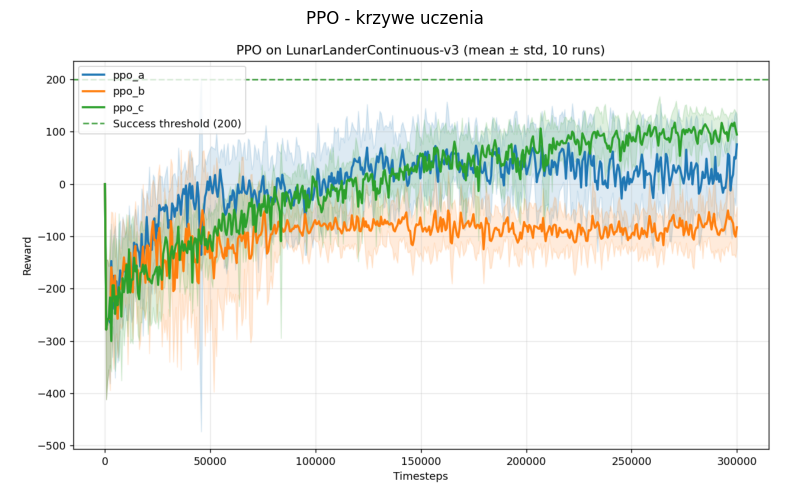

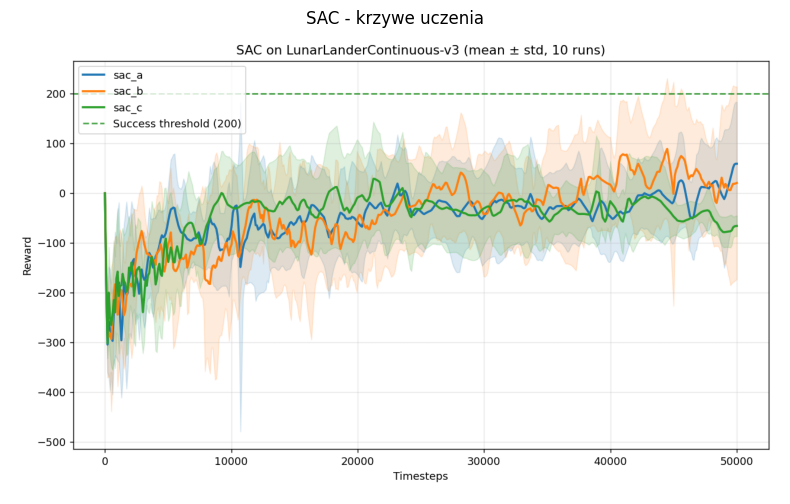

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for algo in ["PPO", "SAC"]:
    curve_path = RESULTS_DIR / algo / "comparison_curve.png"
    if not curve_path.exists():
        print(f"Brak wykresu dla {algo}: {curve_path}")
        continue
    img = mpimg.imread(curve_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{algo} - krzywe uczenia")
    plt.show()

### Opis wyników

- PPO
Krzywa uczenia wskazuje na stopniową naukę w czasie. Na początkowych fazach uczenia wszystkie modele radziły sobie równie dobrze, natomiast pod koniec najlepsze wyniki (średnią reward) zaczął osiągać model z zestawem hiperparamaterów numer a. Hiperparametry w tym przypadku leżą w większości po środku względem b i c. Najlepsze wyniki w końcowej fazie uczenia sięgały okolic 0, czyli modele nie nauczyły się dostatecznie
- SAC
Tutaj wyniki rosły od znacząco poniżej 0 (-300) do okolic 50. Podobnie poradziły sobie modele a i b, natomiast najgorzej c, gdyż u niego widać pogorszenie wyników pod koniec uczenia.


### Dwie architektury

W algorytmie SAC (Soft Actor-Critic) architektura składa się z dwóch rodzajów sieci: Aktora (polityki) oraz Krytyka (funkcji wartości Q). Ponieważ Lunar Lander w wersji ciągłej ma specyficzne wymiary, wejścia i wyjścia wyglądają następująco:

1 **Sieć Aktora (Actor Network)**
- Wejście (State): Wektor 8-wymiarowy reprezentujący stan lądownika (pozycja $x, y$, prędkości liniowe $v_x, v_y$, kąt obrotu, prędkość kątowa oraz dwa wskaźniki binarne kontaktu nóżek z podłożem).
- Wyjście (Action): Wektor 2-wymiarowy określający ciąg silników (silnik główny oraz silniki boczne). Wartości wyjściowe są zazwyczaj mapowane do przedziału $[-1, 1]$ za pomocą funkcji tangensa hiperbolicznego ($\tanh$).

2 **Sieć Krytyka (Critic Network)**
- Wejście (State + Action): Połączenie (konkatenacja) wektora stanu (8) i wektora akcji (2), co daje łącznie wektor 10-wymiarowy. Krytyk ocenia, jak dobra jest dana akcja w danym stanie.
- Wyjście (Q-value): Skalar (1 wymiar), czyli przewidywana skumulowana, zdyskontowana nagroda za podjęcie tej akcji w tym stanie.

### Schemat Architektury "Small" (2x64)

#### AKTOR (Policy)

[Wejście: Stan środowiska (8)]

       ↓

[Warstwa liniowa (Dense / Linear): 8 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 64 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 64 → 2]

       ↓

[Funkcja aktywacji: Tanh]

       ↓

[Wyjście: Akcja ciągła (2)]

#### KRYTYK (Q-Value Function)

[Wejście: Stan (8) + Akcja (2) = Połączony wektor (10)]

       ↓

[Warstwa liniowa (Dense / Linear): 10 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓
[Warstwa liniowa (Dense / Linear): 64 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 64 → 1]

       ↓

[Brak aktywacji / Linear]

       ↓
       
[Wyjście: Wartość Q (1)]

### Schemat Architektury "Large" (2x256)

#### AKTOR (Policy)

[Wejście: Stan środowiska (8)]

       ↓

[Warstwa liniowa (Dense / Linear): 8 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 256 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 256 → 2]

       ↓

[Funkcja aktywacji: Tanh]

       ↓

[Wyjście: Akcja ciągła (2)]

#### KRYTYK (Q-Value Function)

[Wejście: Stan (8) + Akcja (2) = Połączony wektor (10)]

       ↓

[Warstwa liniowa (Dense / Linear): 10 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 256 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 256 → 1]

       ↓

[Brak aktywacji / Linear]

       ↓
       
[Wyjście: Wartość Q (1)]

Obie architektury zostały uczone przez 50 000 kroków, przy takich samych hiperparametrach:
 params={'learning_rate': 0.0003, 'gamma': 0.99, 'tau': 0.005, 'batch_size': 256, 'buffer_size': 300000, 'train_freq': 1, 'gradient_steps': 1}.

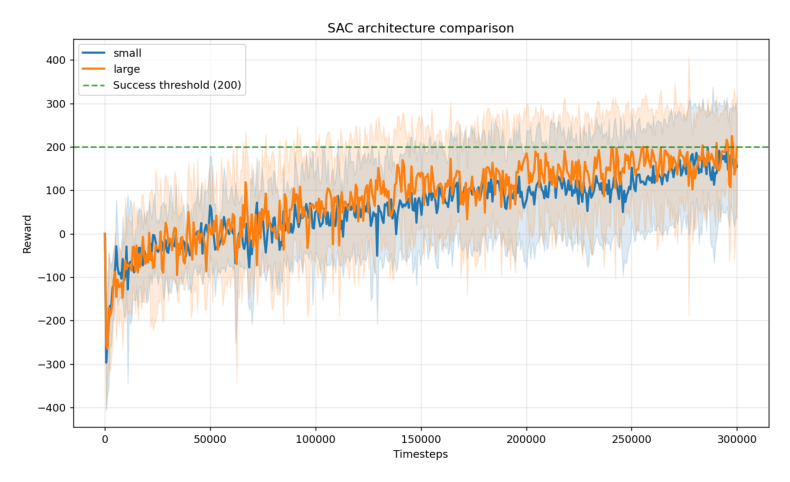

In [9]:
img = mpimg.imread("results/arch_compare/SAC/comparison_curve.png")
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

Z wykresu wynika, że obie architektury (duża i mała) sprawiły się prawie identycznie. Przez cały proces uczenia miały porównywalne nagrody, przez to ciężko powiedzieć, który sprawił się lepiej.

### Symulacje

Najlepszy agent (wg średniej z ostatnich 25% epizodów) został zapisany do results/best_model. Symulacje zostały uruchomione deterministycznie, bez eksploracji przez 10 epizodów.

In [10]:
best_dir = RESULTS_DIR / "best_model"
info_path = best_dir / "best_model_info.json"
eval_path = best_dir / "eval.json"

if info_path.exists():
    with open(info_path, "r", encoding="utf-8") as file:
        info = json.load(file)
    print("Best model:", info)
else:
    print("Brak best_model_info.json")

if eval_path.exists():
    with open(eval_path, "r", encoding="utf-8") as file:
        eval_data = json.load(file)
    print("Eval rewards:", eval_data.get("rewards", []))
    print(f"Eval mean: {eval_data.get('mean'):.1f} ± {eval_data.get('std'):.1f}")
else:
    print("Brak eval.json")

Best model: {'algorithm': 'PPO', 'hyperparam_set': 'ppo_a', 'total_timesteps': 300000}
Eval rewards: [-150.0332773334428, -138.67390405480822, -80.9405959317219, -92.85308130332713, -194.03868373129762, -83.5958609010032, -112.16312292827357, -97.63758783822375, -83.77595832524686, -24.316406105676588]
Eval mean: -105.8 ± 44.0


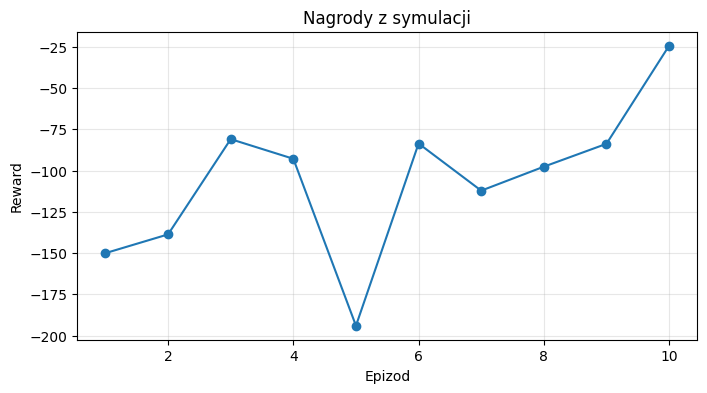

In [11]:
import matplotlib.pyplot as plt

if eval_path.exists():
    rewards = eval_data.get("rewards", [])
    if rewards:
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(rewards) + 1), rewards, marker="o")
        plt.title("Nagrody z symulacji")
        plt.xlabel("Epizod")
        plt.ylabel("Reward")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Brak nagrod w eval.json")

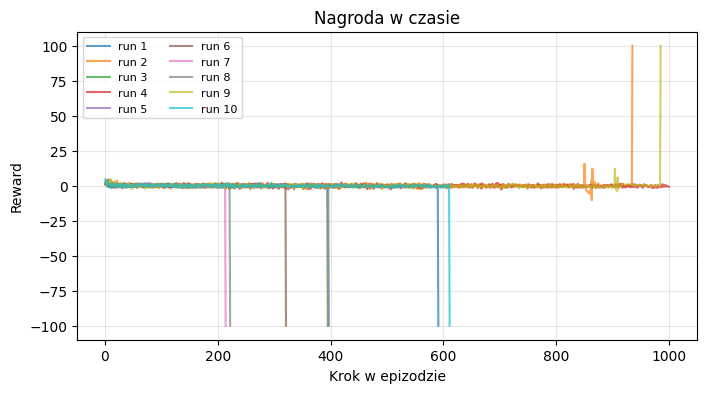

In [12]:
import gymnasium as gym
from stable_baselines3 import PPO, SAC, TD3

algo_map = {"PPO": PPO, "SAC": SAC, "TD3": TD3}

def collect_reward_trajectories(env_id, model_path, algo_name, n_runs=10, seed_start=0):
    env = gym.make(env_id)
    model_cls = algo_map[algo_name]
    model = model_cls.load(model_path)
    trajectories = []
    for i in range(n_runs):
        obs, _ = env.reset(seed=seed_start + i)
        done = False
        rewards = []
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            rewards.append(float(reward))
            done = terminated or truncated
        trajectories.append(rewards)
    env.close()
    return trajectories

if info_path.exists():
    algo_name = info.get("algorithm")
    model_path = str(best_dir / "best_model.zip")
    trajectories = collect_reward_trajectories(
        "LunarLanderContinuous-v3", model_path, algo_name, n_runs=10, seed_start=100
    )
    plt.figure(figsize=(8, 4))
    for idx, rewards in enumerate(trajectories, start=1):
        steps = range(1, len(rewards) + 1)
        plt.plot(steps, rewards, alpha=0.7, label=f"run {idx}")
    plt.title("Nagroda w czasie")
    plt.xlabel("Krok w epizodzie")
    plt.ylabel("Reward")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.show()
else:
    print("Brak best_model_info.json")